In [ ]:
import numpy as np
import h5py

f = h5py.File(
    "resolution_distorsion_expe_dataset_rf.hdf5",
    'r'
)

grp = f['US/US_DATASET0000']

# -------------------------------------------------
# LOAD DATA
# -------------------------------------------------

angles = np.array(grp['angles'])

rf_real = np.array(grp['data/real'])
rf_imag = np.array(grp['data/imag'])

rf_data = rf_real + 1j * rf_imag

probe_geometry = np.array(grp['probe_geometry'])

fs = float(np.array(grp['sampling_frequency']))
c = float(np.array(grp['sound_speed']))

initial_time = float(np.array(grp['initial_time']))

print("RF shape:", rf_data.shape)
print("Angles:", angles.shape)
print("Probe geometry:", probe_geometry.shape)

print("Sampling frequency:", fs)
print("Sound speed:", c)

RF shape: (75, 128, 3328)
Angles: (75,)
Probe geometry: (3, 128)
Sampling frequency: 20832000.0
Sound speed: 1540.0


/tmp/ipykernel_6368/2626151220.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fs = float(np.array(grp['sampling_frequency']))
/tmp/ipykernel_6368/2626151220.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c = float(np.array(grp['sound_speed']))
/tmp/ipykernel_6368/2626151220.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  initial_time = float(np.array(grp['initial_time']))


In [ ]:
import h5py

f = h5py.File(
    "resolution_distorsion_expe_dataset_rf.hdf5",
    'r'
)

print(list(f.keys()))
def print_structure(name, obj):
    print(name)

f.visititems(print_structure)

['US']
US
US/US_DATASET0000
US/US_DATASET0000/PRF
US/US_DATASET0000/angles
US/US_DATASET0000/data
US/US_DATASET0000/data/imag
US/US_DATASET0000/data/real
US/US_DATASET0000/initial_time
US/US_DATASET0000/modulation_frequency
US/US_DATASET0000/probe_geometry
US/US_DATASET0000/sampling_frequency
US/US_DATASET0000/sound_speed


Processing angle 1/75
Processing angle 2/75
Processing angle 3/75
Processing angle 4/75
Processing angle 5/75
Processing angle 6/75
Processing angle 7/75
Processing angle 8/75
Processing angle 9/75
Processing angle 10/75
Processing angle 11/75
Processing angle 12/75
Processing angle 13/75
Processing angle 14/75
Processing angle 15/75
Processing angle 16/75
Processing angle 17/75
Processing angle 18/75
Processing angle 19/75
Processing angle 20/75
Processing angle 21/75
Processing angle 22/75
Processing angle 23/75
Processing angle 24/75
Processing angle 25/75
Processing angle 26/75
Processing angle 27/75
Processing angle 28/75
Processing angle 29/75
Processing angle 30/75
Processing angle 31/75
Processing angle 32/75
Processing angle 33/75
Processing angle 34/75
Processing angle 35/75
Processing angle 36/75
Processing angle 37/75
Processing angle 38/75
Processing angle 39/75
Processing angle 40/75
Processing angle 41/75
Processing angle 42/75
Processing angle 43/75
Processing angle 44/

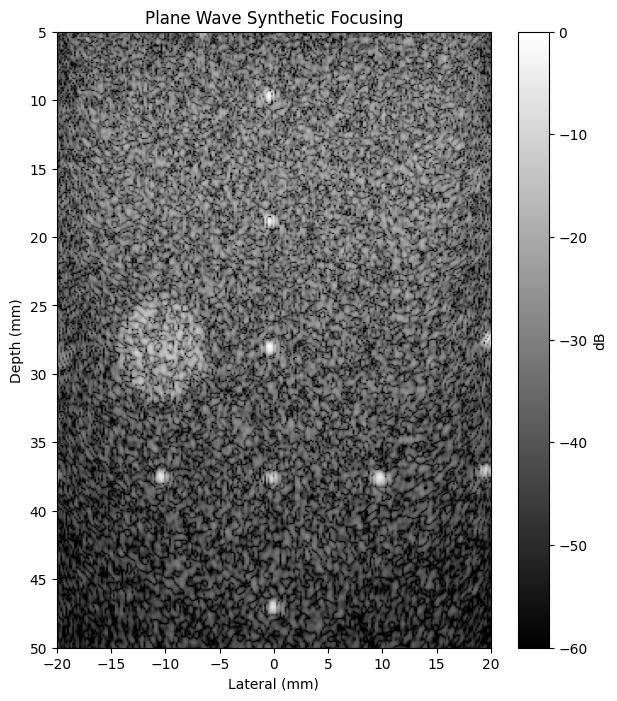

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ============================================================
# PARAMETERS
# ============================================================

n_angles, n_channels, n_samples = rf_data.shape

# probe x positions
x_elements = probe_geometry[0, :]

# image grid
x = np.linspace(-0.02, 0.02, 256)
z = np.linspace(0.005, 0.05, 512)

X, Z = np.meshgrid(x, z)

# output image
final_image = np.zeros((len(z), len(x)), dtype=np.complex64)

# ============================================================
# BEAMFORMING
# ============================================================

for a in range(n_angles):

    print(f"Processing angle {a+1}/{n_angles}")

    theta = angles[a]

    angle_image = np.zeros_like(final_image)

    for ch in range(n_channels):

        x_el = x_elements[ch]

        # ----------------------------------------------------
        # TRANSMIT DELAY
        # ----------------------------------------------------

        tau_tx = (X * np.sin(theta) + Z * np.cos(theta)) / c

        # ----------------------------------------------------
        # RECEIVE DELAY
        # ----------------------------------------------------

        tau_rx = np.sqrt((X - x_el)**2 + Z**2) / c

        # ----------------------------------------------------
        # TOTAL DELAY
        # ----------------------------------------------------

        tau = tau_tx + tau_rx + initial_time

        sample_idx = tau * fs

        # ----------------------------------------------------
        # RF SIGNAL
        # ----------------------------------------------------

        signal = rf_data[a, ch, :]

        interp = interp1d(
            np.arange(n_samples),
            signal,
            kind='linear',
            bounds_error=False,
            fill_value=0
        )

        delayed = interp(sample_idx)

        angle_image += delayed

    # coherent compounding
    final_image += angle_image

# ============================================================
# ENVELOPE DETECTION
# ============================================================

env = np.abs(final_image)

env /= np.max(env)

bmode = 20 * np.log10(env + 1e-12)

# dynamic range clipping
DR = 60
bmode[bmode < -DR] = -DR

# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(7,8))

plt.imshow(
    bmode,
    cmap='gray',
    extent=[
        x[0]*1000,
        x[-1]*1000,
        z[-1]*1000,
        z[0]*1000
    ],
    aspect='auto'
)

plt.xlabel("Lateral (mm)")
plt.ylabel("Depth (mm)")
plt.title("Plane Wave Synthetic Focusing")

plt.colorbar(label='dB')

plt.show()

In [ ]:
import h5py

f = h5py.File(
    "carotid_long_expe_dataset_rf.hdf5",
    'r'
)

print(list(f.keys()))
def print_structure(name, obj):
    print(name)

f.visititems(print_structure)

['US']
US
US/US_DATASET0000
US/US_DATASET0000/PRF
US/US_DATASET0000/angles
US/US_DATASET0000/data
US/US_DATASET0000/data/imag
US/US_DATASET0000/data/real
US/US_DATASET0000/initial_time
US/US_DATASET0000/modulation_frequency
US/US_DATASET0000/probe_geometry
US/US_DATASET0000/sampling_frequency
US/US_DATASET0000/sound_speed


In [ ]:
import numpy as np
import h5py

f = h5py.File(
    "carotid_long_expe_dataset_rf.hdf5",
    'r'
)

grp = f['US/US_DATASET0000']

# -------------------------------------------------
# LOAD DATA
# -------------------------------------------------

angles = np.array(grp['angles'])

rf_real = np.array(grp['data/real'])
rf_imag = np.array(grp['data/imag'])

rf_data_carotid_long = rf_real + 1j * rf_imag

probe_geometry = np.array(grp['probe_geometry'])

fs = float(np.array(grp['sampling_frequency']))
c = float(np.array(grp['sound_speed']))

initial_time = float(np.array(grp['initial_time']))

print("RF shape:", rf_data_carotid_long.shape)
print("Angles:", angles.shape)
print("Probe geometry:", probe_geometry.shape)

print("Sampling frequency:", fs)
print("Sound speed:", c)

RF shape: (75, 128, 1536)
Angles: (75,)
Probe geometry: (3, 128)
Sampling frequency: 20832000.0
Sound speed: 1540.0


/tmp/ipykernel_6368/3447583034.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fs = float(np.array(grp['sampling_frequency']))
/tmp/ipykernel_6368/3447583034.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c = float(np.array(grp['sound_speed']))
/tmp/ipykernel_6368/3447583034.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  initial_time = float(np.array(grp['initial_time']))


Processing angle 1/75
Processing angle 2/75
Processing angle 3/75
Processing angle 4/75
Processing angle 5/75
Processing angle 6/75
Processing angle 7/75
Processing angle 8/75
Processing angle 9/75
Processing angle 10/75
Processing angle 11/75
Processing angle 12/75
Processing angle 13/75
Processing angle 14/75
Processing angle 15/75
Processing angle 16/75
Processing angle 17/75
Processing angle 18/75
Processing angle 19/75
Processing angle 20/75
Processing angle 21/75
Processing angle 22/75
Processing angle 23/75
Processing angle 24/75
Processing angle 25/75
Processing angle 26/75
Processing angle 27/75
Processing angle 28/75
Processing angle 29/75
Processing angle 30/75
Processing angle 31/75
Processing angle 32/75
Processing angle 33/75
Processing angle 34/75
Processing angle 35/75
Processing angle 36/75
Processing angle 37/75
Processing angle 38/75
Processing angle 39/75
Processing angle 40/75
Processing angle 41/75
Processing angle 42/75
Processing angle 43/75
Processing angle 44/

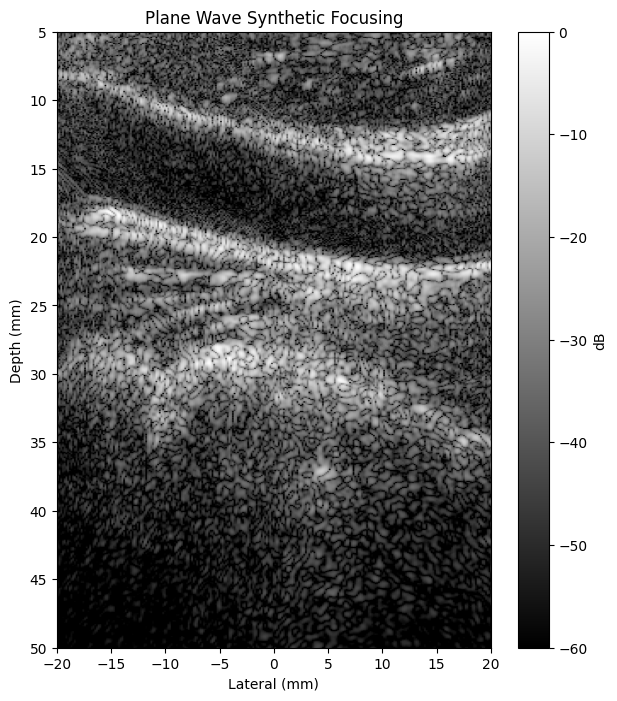

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ============================================================
# PARAMETERS
# ============================================================

n_angles, n_channels, n_samples = rf_data_carotid_long.shape

# probe x positions
x_elements = probe_geometry[0, :]

# image grid
x = np.linspace(-0.02, 0.02, 256)
z = np.linspace(0.005, 0.05, 512)

X, Z = np.meshgrid(x, z)

# output image
final_image = np.zeros((len(z), len(x)), dtype=np.complex64)

# ============================================================
# BEAMFORMING
# ============================================================

for a in range(n_angles):

    print(f"Processing angle {a+1}/{n_angles}")

    theta = angles[a]

    angle_image = np.zeros_like(final_image)

    for ch in range(n_channels):

        x_el = x_elements[ch]

        # ----------------------------------------------------
        # TRANSMIT DELAY
        # ----------------------------------------------------

        tau_tx = (X * np.sin(theta) + Z * np.cos(theta)) / c

        # ----------------------------------------------------
        # RECEIVE DELAY
        # ----------------------------------------------------

        tau_rx = np.sqrt((X - x_el)**2 + Z**2) / c

        # ----------------------------------------------------
        # TOTAL DELAY
        # ----------------------------------------------------

        tau = tau_tx + tau_rx + initial_time

        sample_idx = tau * fs

        # ----------------------------------------------------
        # RF SIGNAL
        # ----------------------------------------------------

        signal = rf_data_carotid_long[a, ch, :]

        interp = interp1d(
            np.arange(n_samples),
            signal,
            kind='linear',
            bounds_error=False,
            fill_value=0
        )

        delayed = interp(sample_idx)

        angle_image += delayed

    # coherent compounding
    final_image += angle_image

# ============================================================
# ENVELOPE DETECTION
# ============================================================

env = np.abs(final_image)

env /= np.max(env)

bmode = 20 * np.log10(env + 1e-12)

# dynamic range clipping
DR = 60
bmode[bmode < -DR] = -DR

# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(7,8))

plt.imshow(
    bmode,
    cmap='gray',
    extent=[
        x[0]*1000,
        x[-1]*1000,
        z[-1]*1000,
        z[0]*1000
    ],
    aspect='auto'
)

plt.xlabel("Lateral (mm)")
plt.ylabel("Depth (mm)")
plt.title("Plane Wave Synthetic Focusing")

plt.colorbar(label='dB')

plt.show()

In [ ]:
import numpy as np
import h5py

f = h5py.File(
    "carotid_cross_expe_dataset_rf.hdf5",
    'r'
)

grp = f['US/US_DATASET0000']

# -------------------------------------------------
# LOAD DATA
# -------------------------------------------------

angles = np.array(grp['angles'])

rf_real = np.array(grp['data/real'])
rf_imag = np.array(grp['data/imag'])

rf_data_carotid_cross = rf_real + 1j * rf_imag

probe_geometry = np.array(grp['probe_geometry'])

fs = float(np.array(grp['sampling_frequency']))
c = float(np.array(grp['sound_speed']))

initial_time = float(np.array(grp['initial_time']))

print("RF shape:", rf_data_carotid_cross.shape)
print("Angles:", angles.shape)
print("Probe geometry:", probe_geometry.shape)

print("Sampling frequency:", fs)
print("Sound speed:", c)

RF shape: (75, 128, 1536)
Angles: (75,)
Probe geometry: (3, 128)
Sampling frequency: 20832000.0
Sound speed: 1540.0


/tmp/ipykernel_6368/1973679631.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fs = float(np.array(grp['sampling_frequency']))
/tmp/ipykernel_6368/1973679631.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c = float(np.array(grp['sound_speed']))
/tmp/ipykernel_6368/1973679631.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  initial_time = float(np.array(grp['initial_time']))


Processing angle 1/75
Processing angle 2/75
Processing angle 3/75
Processing angle 4/75
Processing angle 5/75
Processing angle 6/75
Processing angle 7/75
Processing angle 8/75
Processing angle 9/75
Processing angle 10/75
Processing angle 11/75
Processing angle 12/75
Processing angle 13/75
Processing angle 14/75
Processing angle 15/75
Processing angle 16/75
Processing angle 17/75
Processing angle 18/75
Processing angle 19/75
Processing angle 20/75
Processing angle 21/75
Processing angle 22/75
Processing angle 23/75
Processing angle 24/75
Processing angle 25/75
Processing angle 26/75
Processing angle 27/75
Processing angle 28/75
Processing angle 29/75
Processing angle 30/75
Processing angle 31/75
Processing angle 32/75
Processing angle 33/75
Processing angle 34/75
Processing angle 35/75
Processing angle 36/75
Processing angle 37/75
Processing angle 38/75
Processing angle 39/75
Processing angle 40/75
Processing angle 41/75
Processing angle 42/75
Processing angle 43/75
Processing angle 44/

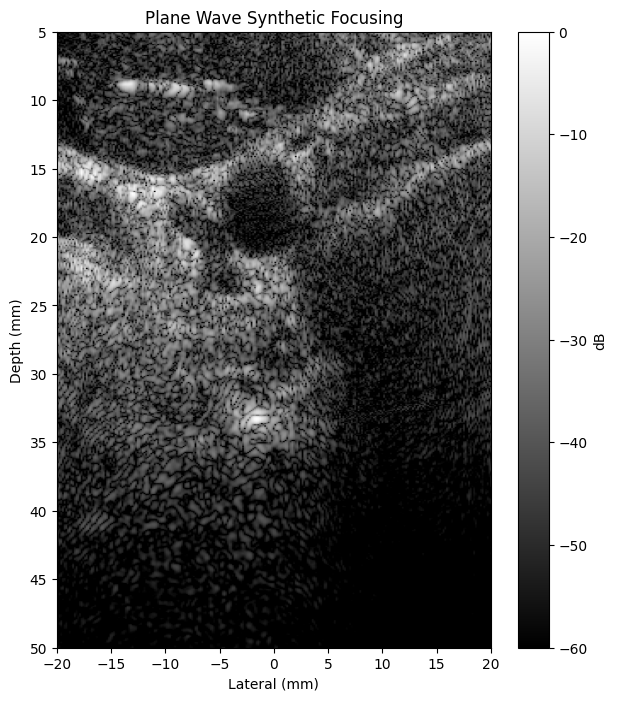

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ============================================================
# PARAMETERS
# ============================================================

n_angles, n_channels, n_samples = rf_data_carotid_cross.shape

# probe x positions
x_elements = probe_geometry[0, :]

# image grid
x = np.linspace(-0.02, 0.02, 256)
z = np.linspace(0.005, 0.05, 512)

X, Z = np.meshgrid(x, z)

# output image
final_image = np.zeros((len(z), len(x)), dtype=np.complex64)

# ============================================================
# BEAMFORMING
# ============================================================

for a in range(n_angles):

    print(f"Processing angle {a+1}/{n_angles}")

    theta = angles[a]

    angle_image = np.zeros_like(final_image)

    for ch in range(n_channels):

        x_el = x_elements[ch]

        # ----------------------------------------------------
        # TRANSMIT DELAY
        # ----------------------------------------------------

        tau_tx = (X * np.sin(theta) + Z * np.cos(theta)) / c

        # ----------------------------------------------------
        # RECEIVE DELAY
        # ----------------------------------------------------

        tau_rx = np.sqrt((X - x_el)**2 + Z**2) / c

        # ----------------------------------------------------
        # TOTAL DELAY
        # ----------------------------------------------------

        tau = tau_tx + tau_rx + initial_time

        sample_idx = tau * fs

        # ----------------------------------------------------
        # RF SIGNAL
        # ----------------------------------------------------

        signal = rf_data_carotid_cross[a, ch, :]

        interp = interp1d(
            np.arange(n_samples),
            signal,
            kind='linear',
            bounds_error=False,
            fill_value=0
        )

        delayed = interp(sample_idx)

        angle_image += delayed

    # coherent compounding
    final_image += angle_image

# ============================================================
# ENVELOPE DETECTION
# ============================================================

env = np.abs(final_image)

env /= np.max(env)

bmode = 20 * np.log10(env + 1e-12)

# dynamic range clipping
DR = 60
bmode[bmode < -DR] = -DR

# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(7,8))

plt.imshow(
    bmode,
    cmap='gray',
    extent=[
        x[0]*1000,
        x[-1]*1000,
        z[-1]*1000,
        z[0]*1000
    ],
    aspect='auto'
)

plt.xlabel("Lateral (mm)")
plt.ylabel("Depth (mm)")
plt.title("Plane Wave Synthetic Focusing")

plt.colorbar(label='dB')

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ============================================================
# PARAMETERS
# ============================================================

n_angles, n_channels, n_samples = rf_data_carotid_long.shape

# probe x positions
x_elements = probe_geometry[0, :]

# image grid
x = np.linspace(-0.02, 0.02, 256)
z = np.linspace(0.005, 0.05, 512)

X, Z = np.meshgrid(x, z)

# output image
final_image = np.zeros((len(z), len(x)), dtype=np.complex64)

# ============================================================
# MV BEAMFORMING
# ============================================================

for a in range(30,45):

    print(f"Processing angle {a+1}/75")

    theta = angles[a]

    angle_image = np.zeros((len(z), len(x)), dtype=np.complex64)

    # --------------------------------------------------------
    # LOOP OVER IMAGE PIXELS
    # --------------------------------------------------------

    for iz in range(len(z)):

        for ix in range(len(x)):

            pixel_signals = np.zeros(n_channels, dtype=np.complex64)

            for ch in range(n_channels):

                x_el = x_elements[ch]

                # transmit delay
                tau_tx = (
                    x[ix] * np.sin(theta)
                    + z[iz] * np.cos(theta)
                ) / c

                # receive delay
                tau_rx = np.sqrt(
                    (x[ix] - x_el)**2 + z[iz]**2
                ) / c

                tau = tau_tx + tau_rx + initial_time

                sample_idx = tau * fs

                signal = rf_data_carotid_long[a, ch, :]

                interp = interp1d(
                    np.arange(n_samples),
                    signal,
                    kind='linear',
                    bounds_error=False,
                    fill_value=0
                )

                pixel_signals[ch] = interp(sample_idx)

            # =================================================
            # MINIMUM VARIANCE (CAPON)
            # =================================================

            x_vec = pixel_signals.reshape(-1,1)

            # covariance matrix
            R = x_vec @ np.conj(x_vec.T)

            # diagonal loading
            epsilon = 1e-3 * np.trace(R) / n_channels

            R += epsilon * np.eye(n_channels)

            # steering vector
            a_vec = np.ones((n_channels,1))

            # inverse covariance
            R_inv = np.linalg.inv(R)

            # MV weights
            numerator = R_inv @ a_vec

            denominator = (
                np.conj(a_vec.T)
                @ R_inv
                @ a_vec
            )

            w = numerator / denominator

            # beamformer output
            y = np.conj(w.T) @ x_vec

            angle_image[iz, ix] = y[0,0]

    # coherent compounding
    final_image += angle_image

# ============================================================
# ENVELOPE DETECTION
# ============================================================

env = np.abs(final_image)

env /= np.max(env)

bmode = 20 * np.log10(env + 1e-12)

# dynamic range clipping
DR = 60
bmode[bmode < -DR] = -DR

# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(7,8))

plt.imshow(
    bmode,
    cmap='gray',
    extent=[
        x[0]*1000,
        x[-1]*1000,
        z[-1]*1000,
        z[0]*1000
    ],
    aspect='auto'
)

plt.xlabel("Lateral (mm)")
plt.ylabel("Depth (mm)")
plt.title("Plane Wave Synthetic Focusing")

plt.colorbar(label='dB')

plt.show()

Processing angle 31/75
Processing angle 32/75
Processing angle 33/75


KeyboardInterrupt: 

Angle 30
Angle 31
Angle 32
Angle 33
Angle 34
Angle 35
Angle 36
Angle 37
Angle 38
Angle 39
Angle 40
Angle 41
Angle 42
Angle 43
Angle 44


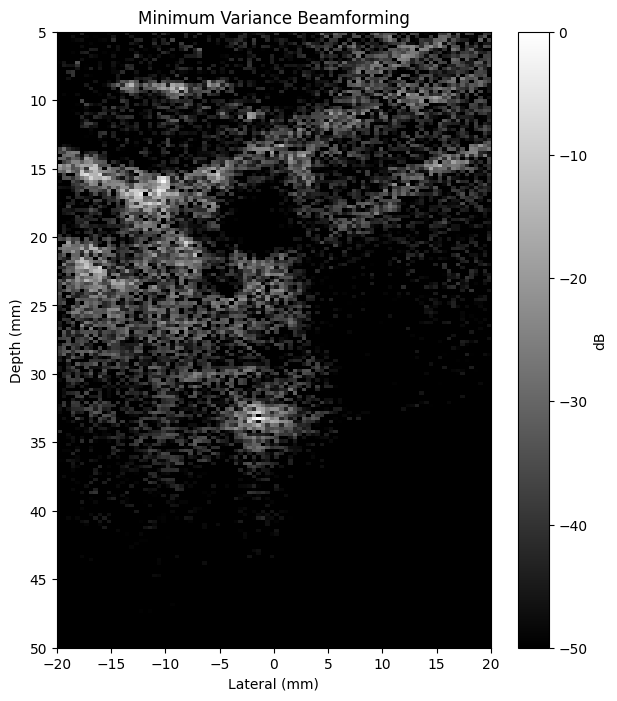

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ============================================================
# SETTINGS
# ============================================================

# Use your RF dataset
rf_data = rf_data_carotid_cross

# Reduced angles for speed
selected_angles = range(30,45)

# Reduced image size
x = np.linspace(-0.02,0.02,96)
z = np.linspace(0.005,0.05,192)

X, Z = np.meshgrid(x,z)

n_angles, n_channels, n_samples = rf_data.shape

x_elements = probe_geometry[0,:]

# output image
final_image_mv = np.zeros((len(z),len(x)),dtype=np.complex64)

# ============================================================
# PRECOMPUTE INTERPOLATORS
# ============================================================

interpolators = []

for a in range(n_angles):

    angle_interps = []

    for ch in range(n_channels):

        interp = interp1d(
            np.arange(n_samples),
            rf_data[a,ch,:],
            kind='linear',
            bounds_error=False,
            fill_value=0
        )

        angle_interps.append(interp)

    interpolators.append(angle_interps)

# ============================================================
# MV BEAMFORMING
# ============================================================

for a in selected_angles:

    print(f"Angle {a}")

    theta = angles[a]

    for iz in range(len(z)):

        for ix in range(len(x)):

            pixel_signals = np.zeros(n_channels,dtype=np.complex64)

            # -----------------------------------------------
            # DELAYED CHANNEL SIGNALS
            # -----------------------------------------------

            for ch in range(n_channels):

                x_el = x_elements[ch]

                tau_tx = (
                    x[ix]*np.sin(theta)
                    + z[iz]*np.cos(theta)
                ) / c

                tau_rx = np.sqrt(
                    (x[ix]-x_el)**2 + z[iz]**2
                ) / c

                tau = tau_tx + tau_rx + initial_time

                sample_idx = tau * fs

                pixel_signals[ch] = (
                    interpolators[a][ch](sample_idx)
                )

            # =================================================
            # SIMPLIFIED MINIMUM VARIANCE
            # =================================================

            # covariance estimate
            R = np.outer(
                pixel_signals,
                np.conj(pixel_signals)
            )

            # diagonal loading
            epsilon = 0.01 * np.trace(R) / n_channels

            R += epsilon * np.eye(n_channels)

            # steering vector
            a_vec = np.ones(n_channels)

            # stable pseudo inverse
            R_inv = np.linalg.pinv(R)

            numerator = R_inv @ a_vec

            denominator = (
                np.conj(a_vec).T
                @ R_inv
                @ a_vec
            )

            w = numerator / denominator

            # MV output
            y = np.conj(w).T @ pixel_signals

            final_image_mv[iz,ix] += y

# ============================================================
# ENVELOPE DETECTION
# ============================================================

env = np.abs(final_image_mv)

env /= np.max(env)

bmode_mv = 20*np.log10(env + 1e-12)

DR = 50

bmode_mv[bmode_mv < -DR] = -DR

# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(7,8))

plt.imshow(
    bmode_mv,
    cmap='gray',
    extent=[
        x[0]*1000,
        x[-1]*1000,
        z[-1]*1000,
        z[0]*1000
    ],
    aspect='auto',
    vmin=-DR,
    vmax=0
)

plt.xlabel("Lateral (mm)")
plt.ylabel("Depth (mm)")
plt.title("Minimum Variance Beamforming")

plt.colorbar(label='dB')

plt.show()